In [1]:
# Autonomous Forest Navigation
# Notebook 05: A* Path Planning

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

OCCUPANCY_MAP_FILE = (
    OUTPUTS_DIR
    / "occupancy_maps"
    / "green_local_occupancy_map.npz"
)

print("PATH PLANNING PROJECT SETUP")
print("=" * 70)

print("Python       :", sys.executable)
print("Working dir  :", CURRENT_DIR)
print("Project root :", PROJECT_ROOT)

print("\nRequired map:")

print(
    f"{OCCUPANCY_MAP_FILE.name:40s} -> "
    f"{'OK' if OCCUPANCY_MAP_FILE.exists() else 'MISSING'}"
)

PATH PLANNING PROJECT SETUP
Python       : D:\Autonomous_Forest_Navigation\forest_env\python.exe
Working dir  : D:\Autonomous_Forest_Navigation\notebooks
Project root : D:\Autonomous_Forest_Navigation

Required map:
green_local_occupancy_map.npz            -> OK


PATH-PLANNING MAP
Grid size          : 280 x 280
Resolution         : 0.25 m/cell
Reachable cells    : 613
Maximum reach      : 10.28 m

START
Grid cell          : (row=140, col=140)
Local position     : (0.12, 0.12) m
Occupancy value    : 0

AUTOMATIC GOAL
Grid cell          : (row=137, col=106)
Local position     : (-8.38, -0.62) m
Straight distance  : 8.53 m
Local clearance    : 0.56 m
Occupancy value    : 0
Reachable          : True


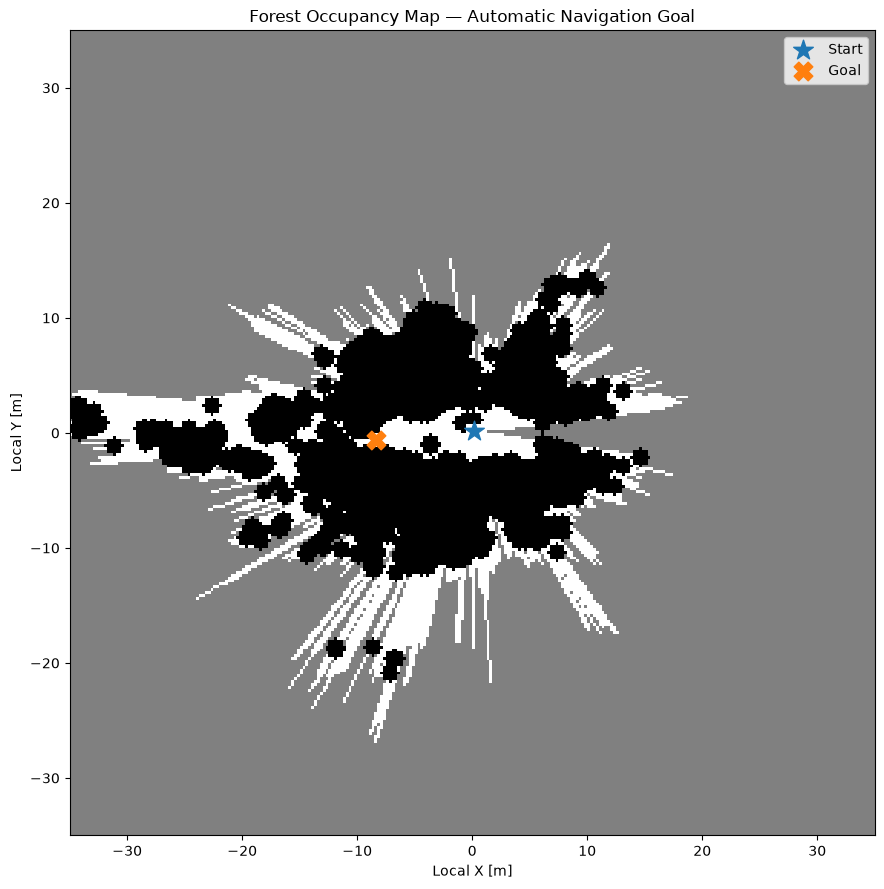


Figure saved:
D:\Autonomous_Forest_Navigation\figures\green_astar_start_goal.png


In [2]:
# Load the occupancy map and automatically select
# a safe, reachable navigation goal.

from scipy.ndimage import distance_transform_edt

# ---------------------------------------------------------
# 1. Load saved occupancy-map data
# ---------------------------------------------------------

map_data = np.load(
    OCCUPANCY_MAP_FILE
)

occupancy_grid = map_data[
    "occupancy_grid"
]

reachable_free = map_data[
    "reachable_free"
].astype(bool)

MAP_RESOLUTION = float(
    map_data["resolution"][0]
)

x_min = float(
    map_data["x_min"][0]
)

x_max = float(
    map_data["x_max"][0]
)

y_min = float(
    map_data["y_min"][0]
)

y_max = float(
    map_data["y_max"][0]
)

robot_row = int(
    map_data["robot_row"][0]
)

robot_col = int(
    map_data["robot_col"][0]
)

grid_height, grid_width = (
    occupancy_grid.shape
)


# ---------------------------------------------------------
# 2. Convert grid cell to local XY coordinate
# ---------------------------------------------------------

def grid_to_xy(row, col):

    x = (
        x_min +
        (col + 0.5) * MAP_RESOLUTION
    )

    y = (
        y_min +
        (row + 0.5) * MAP_RESOLUTION
    )

    return x, y


robot_local_x, robot_local_y = (
    grid_to_xy(
        robot_row,
        robot_col
    )
)


# ---------------------------------------------------------
# 3. Find all reachable cells
# ---------------------------------------------------------

reachable_rows, reachable_cols = np.where(
    reachable_free
)

dx = (
    reachable_cols -
    robot_col
) * MAP_RESOLUTION

dy = (
    reachable_rows -
    robot_row
) * MAP_RESOLUTION

distance_from_robot = np.sqrt(
    dx ** 2 +
    dy ** 2
)

max_distance = (
    distance_from_robot.max()
)


# ---------------------------------------------------------
# 4. Estimate free-space clearance
#
# Distance from each reachable-free cell to the
# boundary of reachable free space.
# ---------------------------------------------------------

clearance_cells = distance_transform_edt(
    reachable_free
)

clearance_m = (
    clearance_cells *
    MAP_RESOLUTION
)

candidate_clearance = clearance_m[
    reachable_rows,
    reachable_cols
]


# ---------------------------------------------------------
# 5. Consider only cells near the far edge
# ---------------------------------------------------------

MIN_GOAL_DISTANCE_RATIO = 0.80

far_mask = (
    distance_from_robot >=
    MIN_GOAL_DISTANCE_RATIO * max_distance
)

candidate_rows = reachable_rows[
    far_mask
]

candidate_cols = reachable_cols[
    far_mask
]

candidate_distances = distance_from_robot[
    far_mask
]

candidate_clearances = candidate_clearance[
    far_mask
]


# ---------------------------------------------------------
# 6. Choose the far candidate with the best clearance
#
# Distance keeps the goal useful.
# Clearance avoids selecting a tiny isolated ray tip.
# ---------------------------------------------------------

if len(candidate_rows) == 0:
    raise RuntimeError(
        "No valid reachable goal candidates found."
    )

distance_score = (
    candidate_distances /
    candidate_distances.max()
)

if candidate_clearances.max() > 0:

    clearance_score = (
        candidate_clearances /
        candidate_clearances.max()
    )

else:

    clearance_score = np.zeros_like(
        candidate_clearances
    )

goal_score = (
    0.70 * distance_score +
    0.30 * clearance_score
)

best_idx = np.argmax(
    goal_score
)

goal_row = int(
    candidate_rows[best_idx]
)

goal_col = int(
    candidate_cols[best_idx]
)

goal_distance = float(
    candidate_distances[best_idx]
)

goal_clearance = float(
    candidate_clearances[best_idx]
)

goal_x, goal_y = grid_to_xy(
    goal_row,
    goal_col
)


# ---------------------------------------------------------
# 7. Verify start and goal
# ---------------------------------------------------------

start_cell_value = occupancy_grid[
    robot_row,
    robot_col
]

goal_cell_value = occupancy_grid[
    goal_row,
    goal_col
]

goal_is_reachable = bool(
    reachable_free[
        goal_row,
        goal_col
    ]
)


# ---------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------

print("PATH-PLANNING MAP")
print("=" * 70)

print(
    f"Grid size          : "
    f"{grid_width} x {grid_height}"
)

print(
    f"Resolution         : "
    f"{MAP_RESOLUTION:.2f} m/cell"
)

print(
    f"Reachable cells    : "
    f"{reachable_free.sum():,}"
)

print(
    f"Maximum reach      : "
    f"{max_distance:.2f} m"
)

print("\nSTART")
print("=" * 70)

print(
    f"Grid cell          : "
    f"(row={robot_row}, col={robot_col})"
)

print(
    f"Local position     : "
    f"({robot_local_x:.2f}, "
    f"{robot_local_y:.2f}) m"
)

print(
    f"Occupancy value    : "
    f"{start_cell_value}"
)

print("\nAUTOMATIC GOAL")
print("=" * 70)

print(
    f"Grid cell          : "
    f"(row={goal_row}, col={goal_col})"
)

print(
    f"Local position     : "
    f"({goal_x:.2f}, {goal_y:.2f}) m"
)

print(
    f"Straight distance  : "
    f"{goal_distance:.2f} m"
)

print(
    f"Local clearance    : "
    f"{goal_clearance:.2f} m"
)

print(
    f"Occupancy value    : "
    f"{goal_cell_value}"
)

print(
    f"Reachable          : "
    f"{goal_is_reachable}"
)


# ---------------------------------------------------------
# 9. Visualize selected start and goal
# ---------------------------------------------------------

display_grid = np.zeros_like(
    occupancy_grid,
    dtype=float
)

# Unknown = gray
display_grid[
    occupancy_grid == -1
] = 0.5

# Free = white
display_grid[
    occupancy_grid == 0
] = 1.0

# Occupied = black
display_grid[
    occupancy_grid == 100
] = 0.0


fig, ax = plt.subplots(
    figsize=(9, 9)
)

ax.imshow(
    display_grid,
    origin="lower",
    extent=[
        x_min,
        x_max,
        y_min,
        y_max
    ],
    cmap="gray",
    interpolation="nearest"
)

ax.scatter(
    robot_local_x,
    robot_local_y,
    marker="*",
    s=220,
    label="Start",
    zorder=5
)

ax.scatter(
    goal_x,
    goal_y,
    marker="X",
    s=180,
    label="Goal",
    zorder=5
)

ax.set_title(
    "Forest Occupancy Map — Automatic Navigation Goal"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.legend()

plt.tight_layout()

goal_figure = (
    FIGURES_DIR /
    "green_astar_start_goal.png"
)

plt.savefig(
    goal_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(goal_figure)

A* PATH PLANNING
Start : (140, 140)
Goal  : (137, 106)
Start traversable: True
Goal traversable : True

A* SEARCH RESULT
Path cells       : 35
Expanded nodes   : 119

PATH METRICS
Straight distance : 8.53 m
A* path length    : 9.02 m
Path efficiency   : 94.6 %


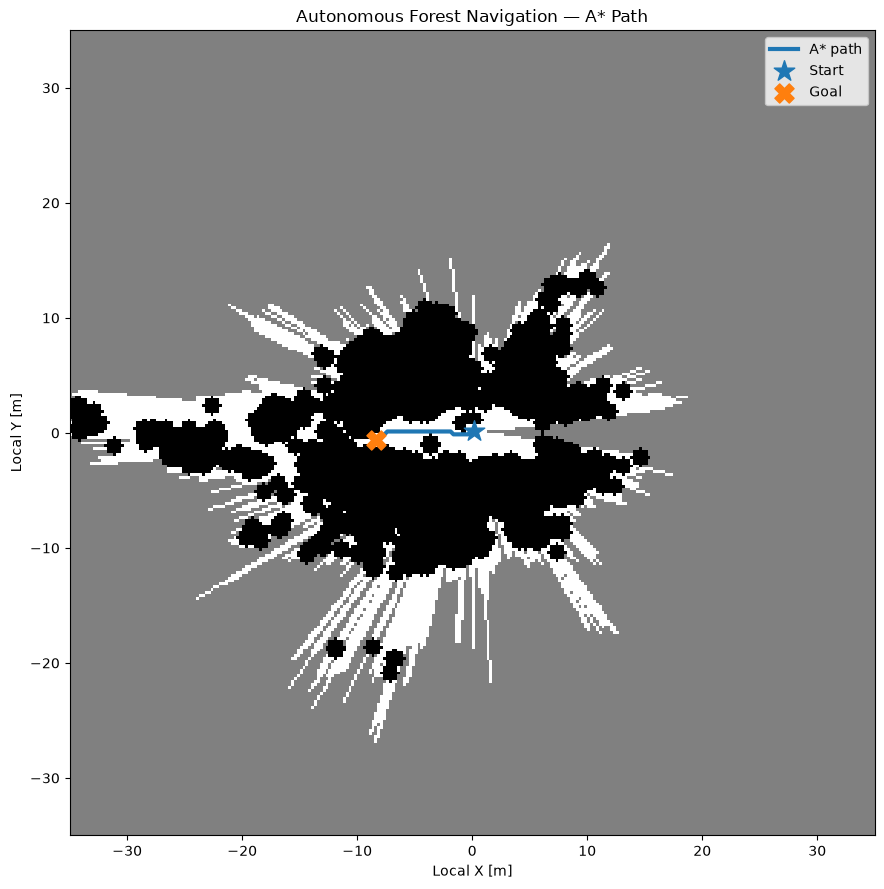


Figure saved:
D:\Autonomous_Forest_Navigation\figures\green_astar_planned_path.png


In [3]:
# Run A* path planning on the known reachable free space

import heapq
import math

# ---------------------------------------------------------
# 1. Traversability map
#
# Only free space connected to the robot is traversable.
# Unknown and occupied cells are forbidden.
# ---------------------------------------------------------

traversable = reachable_free.copy()

start = (
    robot_row,
    robot_col
)

goal = (
    goal_row,
    goal_col
)

print("A* PATH PLANNING")
print("=" * 70)

print("Start :", start)
print("Goal  :", goal)

print(
    "Start traversable:",
    bool(traversable[start])
)

print(
    "Goal traversable :",
    bool(traversable[goal])
)


# ---------------------------------------------------------
# 2. 8-connected motion model
# ---------------------------------------------------------

motions = [
    (-1,  0, 1.0),          # down/up in grid
    ( 1,  0, 1.0),
    ( 0, -1, 1.0),
    ( 0,  1, 1.0),

    (-1, -1, math.sqrt(2)),
    (-1,  1, math.sqrt(2)),
    ( 1, -1, math.sqrt(2)),
    ( 1,  1, math.sqrt(2))
]


# ---------------------------------------------------------
# 3. Octile-distance heuristic
#
# Appropriate for 8-connected grids.
# ---------------------------------------------------------

def heuristic(cell, goal):

    row, col = cell
    goal_row_, goal_col_ = goal

    dx = abs(
        col - goal_col_
    )

    dy = abs(
        row - goal_row_
    )

    return (
        max(dx, dy)
        +
        (math.sqrt(2) - 1)
        * min(dx, dy)
    )


# ---------------------------------------------------------
# 4. Reconstruct path
# ---------------------------------------------------------

def reconstruct_path(
    came_from,
    current
):

    path = [current]

    while current in came_from:

        current = came_from[
            current
        ]

        path.append(
            current
        )

    path.reverse()

    return path


# ---------------------------------------------------------
# 5. A* search
# ---------------------------------------------------------

def astar(
    traversable,
    start,
    goal
):

    rows, cols = (
        traversable.shape
    )

    open_heap = []

    heapq.heappush(
        open_heap,
        (
            heuristic(
                start,
                goal
            ),
            0.0,
            start
        )
    )

    came_from = {}

    g_score = {
        start: 0.0
    }

    closed = set()

    expanded_nodes = 0


    while open_heap:

        _, current_g, current = (
            heapq.heappop(
                open_heap
            )
        )

        if current in closed:
            continue

        closed.add(
            current
        )

        expanded_nodes += 1


        # Goal reached
        if current == goal:

            path = reconstruct_path(
                came_from,
                current
            )

            return (
                path,
                current_g,
                expanded_nodes
            )


        current_row, current_col = (
            current
        )


        for (
            dr,
            dc,
            motion_cost
        ) in motions:

            next_row = (
                current_row + dr
            )

            next_col = (
                current_col + dc
            )


            # -----------------------------
            # Grid boundary check
            # -----------------------------

            if not (
                0 <= next_row < rows
                and
                0 <= next_col < cols
            ):
                continue


            # -----------------------------
            # Target cell must be free
            # -----------------------------

            if not traversable[
                next_row,
                next_col
            ]:
                continue


            # -----------------------------
            # Prevent diagonal corner cutting
            #
            # For a diagonal step, both
            # adjacent cardinal cells must
            # also be traversable.
            # -----------------------------

            if (
                dr != 0
                and
                dc != 0
            ):

                side_1 = (
                    current_row + dr,
                    current_col
                )

                side_2 = (
                    current_row,
                    current_col + dc
                )

                if not (
                    traversable[
                        side_1
                    ]
                    and
                    traversable[
                        side_2
                    ]
                ):
                    continue


            neighbor = (
                next_row,
                next_col
            )

            tentative_g = (
                current_g +
                motion_cost
            )


            if tentative_g < g_score.get(
                neighbor,
                float("inf")
            ):

                came_from[
                    neighbor
                ] = current

                g_score[
                    neighbor
                ] = tentative_g

                f_score = (
                    tentative_g
                    +
                    heuristic(
                        neighbor,
                        goal
                    )
                )

                heapq.heappush(
                    open_heap,
                    (
                        f_score,
                        tentative_g,
                        neighbor
                    )
                )


    return (
        None,
        float("inf"),
        expanded_nodes
    )


# ---------------------------------------------------------
# 6. Run A*
# ---------------------------------------------------------

path_cells, path_cost_cells, expanded_nodes = (
    astar(
        traversable,
        start,
        goal
    )
)

if path_cells is None:

    raise RuntimeError(
        "A* could not find a path."
    )


print("\nA* SEARCH RESULT")
print("=" * 70)

print(
    f"Path cells       : "
    f"{len(path_cells):,}"
)

print(
    f"Expanded nodes   : "
    f"{expanded_nodes:,}"
)


# ---------------------------------------------------------
# 7. Convert grid path to local metric coordinates
# ---------------------------------------------------------

path_xy = np.array([
    grid_to_xy(
        row,
        col
    )
    for row, col in path_cells
])


# ---------------------------------------------------------
# 8. Calculate path length in metres
# ---------------------------------------------------------

path_segments = np.diff(
    path_xy,
    axis=0
)

path_segment_lengths = np.linalg.norm(
    path_segments,
    axis=1
)

path_length_m = (
    path_segment_lengths.sum()
)

straight_distance_m = np.linalg.norm(
    path_xy[-1] -
    path_xy[0]
)

path_efficiency = (
    straight_distance_m /
    path_length_m
    if path_length_m > 0
    else 1.0
)


print("\nPATH METRICS")
print("=" * 70)

print(
    f"Straight distance : "
    f"{straight_distance_m:.2f} m"
)

print(
    f"A* path length    : "
    f"{path_length_m:.2f} m"
)

print(
    f"Path efficiency   : "
    f"{100 * path_efficiency:.1f} %"
)


# ---------------------------------------------------------
# 9. Plot final A* path
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 9)
)

ax.imshow(
    display_grid,
    origin="lower",
    extent=[
        x_min,
        x_max,
        y_min,
        y_max
    ],
    cmap="gray",
    interpolation="nearest"
)

ax.plot(
    path_xy[:, 0],
    path_xy[:, 1],
    linewidth=3,
    label="A* path"
)

ax.scatter(
    path_xy[0, 0],
    path_xy[0, 1],
    marker="*",
    s=240,
    zorder=6,
    label="Start"
)

ax.scatter(
    path_xy[-1, 0],
    path_xy[-1, 1],
    marker="X",
    s=190,
    zorder=6,
    label="Goal"
)

ax.set_title(
    "Autonomous Forest Navigation — A* Path"
)

ax.set_xlabel(
    "Local X [m]"
)

ax.set_ylabel(
    "Local Y [m]"
)

ax.legend()

plt.tight_layout()

astar_figure = (
    FIGURES_DIR /
    "green_astar_planned_path.png"
)

plt.savefig(
    astar_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigure saved:")
print(astar_figure)

In [4]:
# Save the final A* navigation path and planning metrics

# ---------------------------------------------------------
# 1. Calculate waypoint headings and cumulative distance
# ---------------------------------------------------------

waypoint_segments = np.diff(
    path_xy,
    axis=0
)

segment_lengths = np.linalg.norm(
    waypoint_segments,
    axis=1
)

cumulative_distance = np.concatenate([
    [0.0],
    np.cumsum(segment_lengths)
])

# Heading toward the next waypoint
waypoint_heading = np.zeros(
    len(path_xy)
)

if len(path_xy) > 1:

    waypoint_heading[:-1] = np.arctan2(
        waypoint_segments[:, 1],
        waypoint_segments[:, 0]
    )

    # Last waypoint keeps the previous heading
    waypoint_heading[-1] = (
        waypoint_heading[-2]
    )


# ---------------------------------------------------------
# 2. Create waypoint table
# ---------------------------------------------------------

waypoints = pd.DataFrame({
    "waypoint": np.arange(
        len(path_xy)
    ),

    "x_local_m": path_xy[:, 0],
    "y_local_m": path_xy[:, 1],

    "heading_rad": waypoint_heading,
    "heading_deg": np.degrees(
        waypoint_heading
    ),

    "cumulative_distance_m": (
        cumulative_distance
    )
})


# ---------------------------------------------------------
# 3. Save waypoint CSV
# ---------------------------------------------------------

PATH_OUTPUT_DIR = (
    OUTPUTS_DIR /
    "path_planning"
)

PATH_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

WAYPOINT_FILE = (
    PATH_OUTPUT_DIR /
    "green_astar_waypoints.csv"
)

waypoints.to_csv(
    WAYPOINT_FILE,
    index=False
)


# ---------------------------------------------------------
# 4. Save planning metrics
# ---------------------------------------------------------

planning_metrics = pd.DataFrame({
    "Metric": [
        "Straight-line distance [m]",
        "A* path length [m]",
        "Path efficiency [%]",
        "Number of path cells",
        "Expanded A* nodes",
        "Map resolution [m/cell]",
        "Robot radius [m]",
        "Safety margin [m]"
    ],

    "Value": [
        straight_distance_m,
        path_length_m,
        100 * path_efficiency,
        len(path_cells),
        expanded_nodes,
        MAP_RESOLUTION,
        float(map_data["robot_radius"][0]),
        float(map_data["safety_margin"][0])
    ]
})

METRICS_FILE = (
    PATH_OUTPUT_DIR /
    "green_astar_metrics.csv"
)

planning_metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ---------------------------------------------------------
# 5. Final summary
# ---------------------------------------------------------

print("AUTONOMOUS PATH PLANNING RESULTS SAVED")
print("=" * 70)

print("\nWaypoints:")
print(WAYPOINT_FILE)

print("\nMetrics:")
print(METRICS_FILE)

print("\nFINAL PATH")
print("=" * 70)

print(
    f"Waypoints          : "
    f"{len(waypoints)}"
)

print(
    f"Straight distance  : "
    f"{straight_distance_m:.2f} m"
)

print(
    f"A* path length     : "
    f"{path_length_m:.2f} m"
)

print(
    f"Path efficiency    : "
    f"{100 * path_efficiency:.1f} %"
)

print("\nFirst 5 waypoints:")
display(
    waypoints.head()
)

AUTONOMOUS PATH PLANNING RESULTS SAVED

Waypoints:
D:\Autonomous_Forest_Navigation\outputs\path_planning\green_astar_waypoints.csv

Metrics:
D:\Autonomous_Forest_Navigation\outputs\path_planning\green_astar_metrics.csv

FINAL PATH
Waypoints          : 35
Straight distance  : 8.53 m
A* path length     : 9.02 m
Path efficiency    : 94.6 %

First 5 waypoints:


,waypoint,x_local_m,y_local_m,heading_rad,heading_deg,cumulative_distance_m
0,0,0.125,0.125,3.141593,180.0,0.000000
1,1,-0.125,0.125,-2.356194,-135.0,0.250000
2,2,-0.375,-0.125,3.141593,180.0,0.603553
3,3,-0.625,-0.125,3.141593,180.0,0.853553
4,4,-0.875,-0.125,3.141593,180.0,1.103553
